# Tugas 1 – Data Preprocessing
Dataset: `dataset_tugas1_preprocessing.csv`

Langkah dikerjakan berurutan sesuai Tahap 1 – 7.

## Tahap 1: Load Dataset
Impor library yang diperlukan lalu baca file CSV ke dalam DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset_tugas1_preprocessing.csv')
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


## Tahap 2: Eksplorasi Awal (EDA)

**2.1 Cek struktur dan tipe data**

In [2]:
print('Jumlah baris & kolom:', df.shape)
print()
df.info()

Jumlah baris & kolom: (99, 8)

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     str    
 1   Nama           99 non-null     str    
 2   Jenis_Kelamin  99 non-null     str    
 3   Prodi          99 non-null     str    
 4   Status         99 non-null     str    
 5   Nilai_Akhir    70 non-null     str    
 6   Tanggal_Ujian  99 non-null     str    
 7   Umur           90 non-null     float64
dtypes: float64(1), str(7)
memory usage: 6.3 KB


**2.2 Jumlah nilai hilang per kolom**

In [3]:
df.isnull().sum()

ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64

**2.3 Statistik deskriptif**

Kolom numerik (`Umur`) dan kolom kategorikal ditampilkan terpisah agar mudah dibaca.

In [4]:
print('=== Statistik kolom numerik ===')
display(df.describe())
print()
print('=== Statistik kolom kategorikal ===')
display(df.describe(exclude='number'))

=== Statistik kolom numerik ===


,Umur
count,90.000000
mean,23.366667
std,3.763963
min,18.000000
25%,20.000000
50%,23.000000
75%,26.000000
max,30.000000



=== Statistik kolom kategorikal ===


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian
count,99,99,99,99,99,70,99
unique,99,10,2,4,4,5,97
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31
freq,1,15,50,28,29,17,2


## Tahap 3: Menangani Missing Values
Pemilihan metode imputasi:
- **`Umur`** adalah data numerik → diisi dengan **median** (tidak terpengaruh outlier).
- **`Nilai_Akhir`** adalah data kategorikal (A–E) → tidak bisa dirata-rata, sehingga diisi dengan **modus** (nilai yang paling sering muncul).

In [5]:
print('Missing value SEBELUM imputasi:')
print(df[['Nilai_Akhir', 'Umur']].isnull().sum())

median_umur = df['Umur'].median()
modus_nilai = df['Nilai_Akhir'].mode()[0]
print(f'\nMedian Umur       : {median_umur}')
print(f'Modus Nilai_Akhir : {modus_nilai}')

df['Umur'] = df['Umur'].fillna(median_umur)
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(modus_nilai)

print('\nMissing value SESUDAH imputasi:')
print(df.isnull().sum())

Missing value SEBELUM imputasi:
Nilai_Akhir    29
Umur            9
dtype: int64

Median Umur       : 23.0
Modus Nilai_Akhir : C

Missing value SESUDAH imputasi:
ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


## Tahap 4: Normalisasi Format Tanggal
Kolom `Tanggal_Ujian` memiliki **dua format berbeda**: `dd-mm-yyyy` (mis. 13-04-2020) dan `yyyy/mm/dd` (mis. 2020/12/11). Setiap format di-parse secara eksplisit lalu digabung, supaya tidak terjadi salah tafsir antara hari dan bulan.

In [6]:
tgl_a = pd.to_datetime(df['Tanggal_Ujian'], format='%d-%m-%Y', errors='coerce')
tgl_b = pd.to_datetime(df['Tanggal_Ujian'], format='%Y/%m/%d', errors='coerce')
df['Tanggal_Ujian'] = tgl_a.fillna(tgl_b)

print('Tipe data :', df['Tanggal_Ujian'].dtype)
print('Tanggal gagal dikonversi:', df['Tanggal_Ujian'].isnull().sum())
df[['ID', 'Tanggal_Ujian']].head(12)

Tipe data : datetime64[us]
Tanggal gagal dikonversi: 0


,ID,Tanggal_Ujian
0,MH001,2020-04-13
1,MH002,2020-12-11
2,MH003,2021-11-21
3,MH004,2021-08-19
4,MH005,2020-01-05
5,MH006,2021-10-15
6,MH007,2020-01-15
7,MH008,2020-09-16
8,MH009,2021-02-06
9,MH010,2020-02-12


## Tahap 5: Encoding Label
Label Encoding pada kolom `Nama`, `Jenis_Kelamin`, `Prodi`, `Status`, `Nilai_Akhir`.

Salinan data sebelum di-encode (`df_clean`) disimpan agar visualisasi di Tahap 7 tetap menampilkan label asli (nama prodi), bukan angka.

In [7]:
df_clean = df.copy()      # versi bersih (label asli) untuk visualisasi

kolom_kategorikal = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']
df_encoded = df.copy()
encoders = {}

for kol in kolom_kategorikal:
    le = LabelEncoder()
    df_encoded[kol] = le.fit_transform(df_encoded[kol])
    encoders[kol] = le
    print(f'{kol}:', {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))})

print()
df_encoded.head()

Nama: {'Adi': 0, 'Budi': 1, 'Citra': 2, 'Dina': 3, 'Eka': 4, 'Farhan': 5, 'Gita': 6, 'Hana': 7, 'Iwan': 8, 'Joko': 9}
Jenis_Kelamin: {'Laki-laki': 0, 'Perempuan': 1}
Prodi: {'Data Science': 0, 'Informatika': 1, 'Sistem Informasi': 2, 'Teknik Komputer': 3}
Status: {'Aktif': 0, 'Cuti': 1, 'DO': 2, 'Lulus': 3}
Nilai_Akhir: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}



,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


## Tahap 6: Split Data
Data dibagi menjadi **80% data latih** dan **20% data uji** dengan `random_state=42` agar hasilnya reproducible.

In [8]:
data_latih, data_uji = train_test_split(df_encoded, test_size=0.2, random_state=42)

print('Total data  :', len(df_encoded))
print('Data latih  :', data_latih.shape, f'({len(data_latih)/len(df_encoded):.0%})')
print('Data uji    :', data_uji.shape, f'({len(data_uji)/len(df_encoded):.0%})')

Total data  : 99
Data latih  : (79, 8) (80%)
Data uji    : (20, 8) (20%)


## Tahap 7: Visualisasi

**7.1 Histogram kolom Umur**

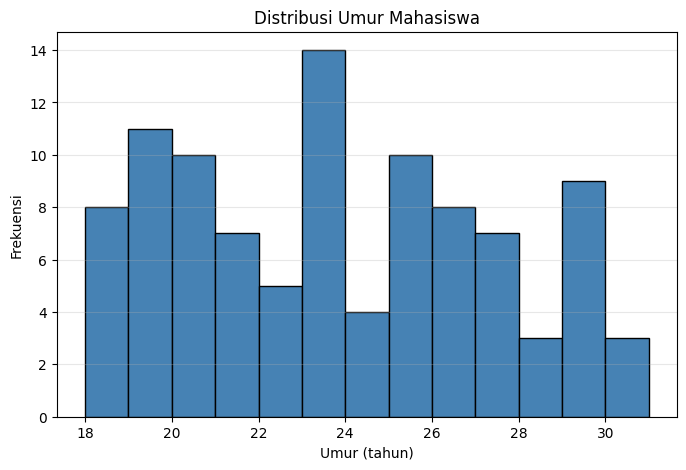

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Umur'], bins=range(18, 32), color='steelblue', edgecolor='black')
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur (tahun)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)
plt.show()

**7.2 Grafik batang jumlah mahasiswa per Prodi**

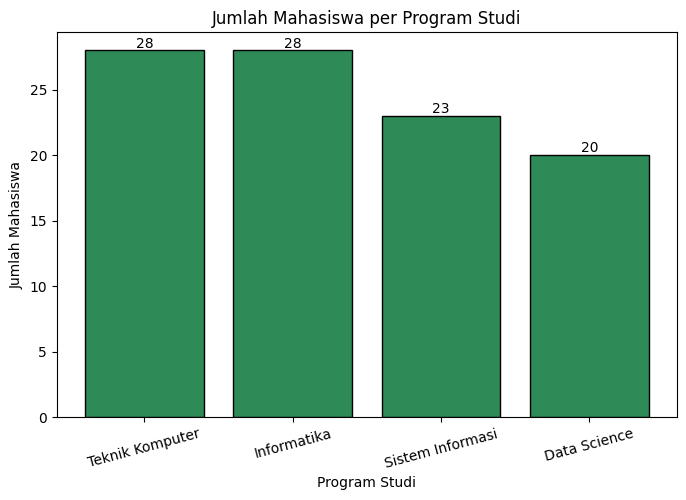

In [10]:
jumlah_prodi = df_clean['Prodi'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(jumlah_prodi.index, jumlah_prodi.values, color='seagreen', edgecolor='black')
plt.bar_label(bars)
plt.title('Jumlah Mahasiswa per Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=15)
plt.show()